In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from datetime import datetime


plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette("crest")


df = pd.read_csv('../data/Processed/online_retail_CLEAN.csv', parse_dates=['InvoiceDate'])

print(f"✅ Dataset cargado: {len(df):,} filas")
df.head()

✅ Dataset cargado: 805,549 filas


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalVenta,Mes,Anio,DiaSemana
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,Reino Unido,83.4,12,2009,Martes
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,Reino Unido,81.0,12,2009,Martes
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,Reino Unido,81.0,12,2009,Martes
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,Reino Unido,100.8,12,2009,Martes
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,Reino Unido,30.0,12,2009,Martes


In [2]:
fecha_referencia = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"Última compra en el dataset: {df['InvoiceDate'].max().date()}")
print(f"Fecha de referencia (nuestro 'hoy'): {fecha_referencia.date()}")

Última compra en el dataset: 2011-12-09
Fecha de referencia (nuestro 'hoy'): 2011-12-10


In [3]:

rfm = df.groupby('Customer ID').agg(
    
    Recency   = ('InvoiceDate', lambda x: (fecha_referencia - x.max()).days),
    
    Frequency = ('Invoice', 'nunique'),
    
    Monetary  = ('TotalVenta', 'sum')

).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f"Clientes únicos analizados: {len(rfm):,}")
print()
rfm.head(10)

Clientes únicos analizados: 5,878



,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40
5,12351.0,375,1,300.93
6,12352.0,36,10,2849.84
7,12353.0,204,2,406.76
8,12354.0,232,1,1079.40
9,12355.0,214,2,947.61


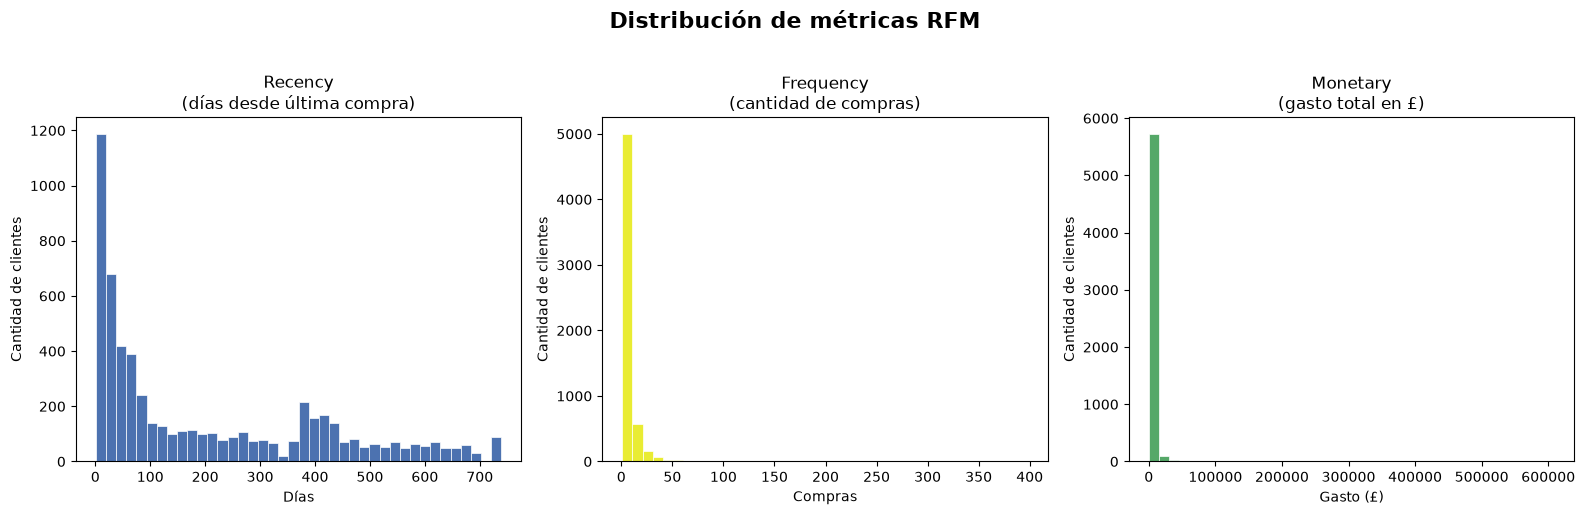

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de métricas RFM', fontsize=16, fontweight='bold', y=1.02)

# Gráfico 1: Recency
axes[0].hist(rfm['Recency'], bins=40, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].set_title('Recency\n(días desde última compra)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Cantidad de clientes')

# Gráfico 2: Frequency
axes[1].hist(rfm['Frequency'], bins=40, color="#E9EC33", edgecolor='white', linewidth=0.5)
axes[1].set_title('Frequency\n(cantidad de compras)')
axes[1].set_xlabel('Compras')
axes[1].set_ylabel('Cantidad de clientes')

# Gráfico 3: Monetary
axes[2].hist(rfm['Monetary'], bins=40, color='#55A868', edgecolor='white', linewidth=0.5)
axes[2].set_title('Monetary\n(gasto total en £)')
axes[2].set_xlabel('Gasto (£)')
axes[2].set_ylabel('Cantidad de clientes')

plt.tight_layout()
plt.show()



In [5]:
# Cada cliente recibe un puntaje del 1 al 4
rfm['R_score'] = pd.qcut(rfm['Recency'],
                          q=4,
                          labels=[4, 3, 2, 1])  


rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=4,
                          labels=[1, 2, 3, 4]) 


rfm['M_score'] = pd.qcut(rfm['Monetary'],
                          q=4,
                          labels=[1, 2, 3, 4]) 


rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)


rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print("Puntajes asignados. Rango posible: 3 (peor) a 12 (mejor)")
print()
rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 
     'R_score', 'F_score', 'M_score', 'RFM_score']].head(10)

Puntajes asignados. Rango posible: 3 (peor) a 12 (mejor)



,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,12346.0,326,12,77556.46,2,4,4,10
1,12347.0,2,8,5633.32,4,4,4,12
2,12348.0,75,5,2019.40,3,3,3,9
3,12349.0,19,4,4428.69,4,3,4,11
4,12350.0,310,1,334.40,2,1,1,4
5,12351.0,375,1,300.93,2,1,1,4
6,12352.0,36,10,2849.84,3,4,4,11
7,12353.0,204,2,406.76,2,2,2,6
8,12354.0,232,1,1079.40,2,1,3,6
9,12355.0,214,2,947.61,2,2,3,7


In [6]:
def asignar_segmento(row):
    r = row['R_score']
    f = row['F_score']
    
    if r >= 4 and f >= 4:
        return 'Campeones'           # Compraron hace poco Y muchas veces
    elif r >= 3 and f >= 3:
        return 'Clientes leales'     # Compran frecuente y son recientes
    elif r >= 4 and f <= 2:
        return 'Nuevos clientes'     # Compraron hace poco pero pocas veces
    elif r >= 3 and f <= 2:
        return 'Prometedores'        # Recientes pero no tan frecuentes aún
    elif r <= 2 and f >= 3:
        return 'En riesgo'           # Compraban seguido pero hace tiempo que no
    elif r <= 2 and f >= 4:
        return 'No perder'           # Fueron muy fieles pero se están yendo
    elif r == 1 and f == 1:
        return 'Hibernando'          # Hace mucho que no compran y pocas veces
    else:
        return 'Necesitan atención'  # El resto


rfm['Segmento'] = rfm.apply(asignar_segmento, axis=1)


resumen = rfm['Segmento'].value_counts().reset_index()
resumen.columns = ['Segmento', 'Clientes']
resumen['Porcentaje'] = (resumen['Clientes'] / len(rfm) * 100).round(1)

print(resumen.to_string(index=False))

          Segmento  Clientes  Porcentaje
   Clientes leales      1285        21.9
Necesitan atención      1273        21.7
         En riesgo       880        15.0
         Campeones       774        13.2
        Hibernando       772        13.1
      Prometedores       558         9.5
   Nuevos clientes       336         5.7


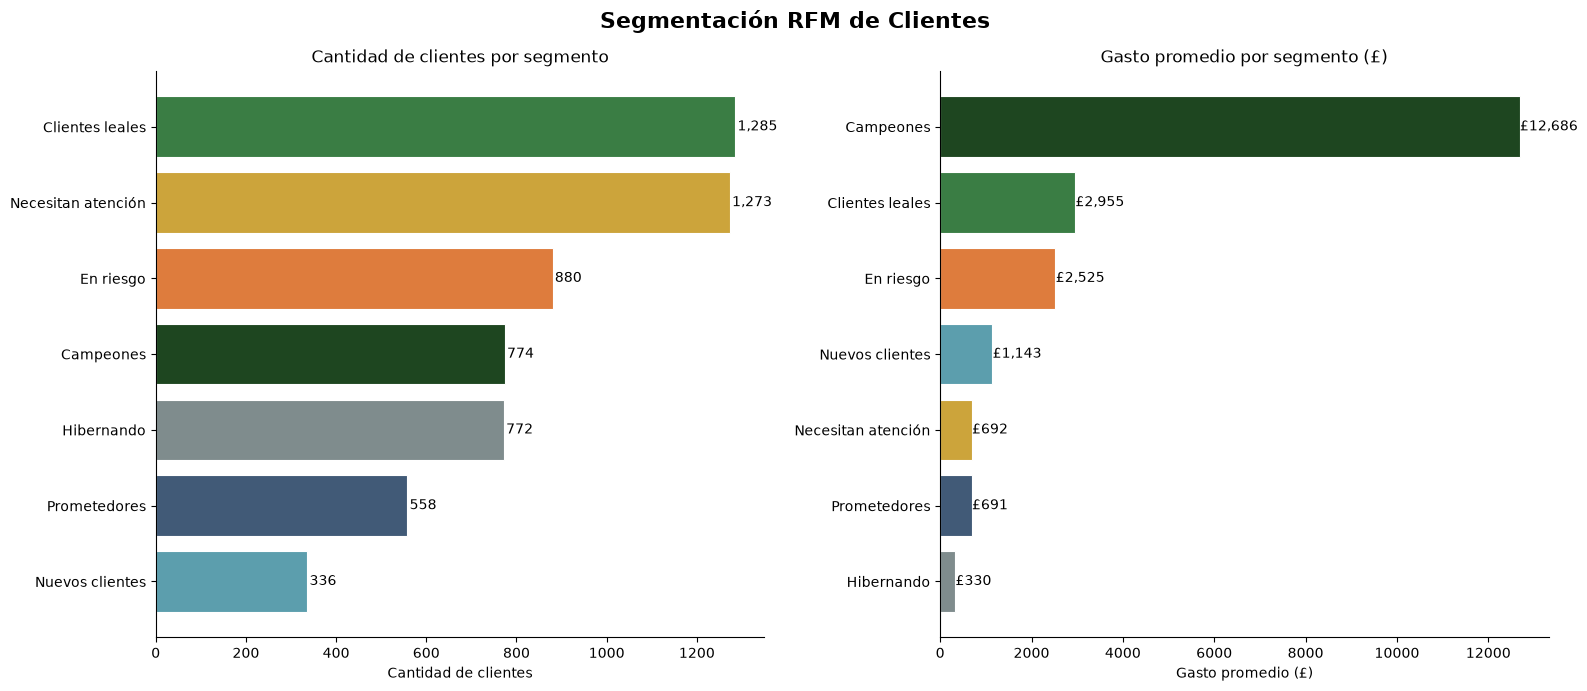

In [7]:

resumen_completo = rfm.groupby('Segmento').agg(
    Clientes  = ('Customer ID', 'count'),
    Recency   = ('Recency', 'mean'),
    Frequency = ('Frequency', 'mean'),
    Monetary  = ('Monetary', 'mean')
).round(1).reset_index()


colores = {
    'Campeones':          '#1e4620',
    'Clientes leales':    '#3a7d44',
    'Nuevos clientes':    '#5c9ead',
    'Prometedores':       '#415a77',
    'En riesgo':          '#de7c3d',
    'No perder':          '#9e2a2b',
    'Necesitan atención': '#cca43b',
    'Hibernando':         '#7f8c8d'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Segmentación RFM de Clientes', fontsize=16, fontweight='bold')


segmentos_ord = resumen_completo.sort_values('Clientes', ascending=True)
bars = ax1.barh(
    segmentos_ord['Segmento'],
    segmentos_ord['Clientes'],
    color=[colores[s] for s in segmentos_ord['Segmento']],
    edgecolor='white', linewidth=0.8
)

for bar, val in zip(bars, segmentos_ord['Clientes']):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)
ax1.set_title('Cantidad de clientes por segmento')
ax1.set_xlabel('Cantidad de clientes')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


segmentos_ord2 = resumen_completo.sort_values('Monetary', ascending=True)
bars2 = ax2.barh(
    segmentos_ord2['Segmento'],
    segmentos_ord2['Monetary'],
    color=[colores[s] for s in segmentos_ord2['Segmento']],
    edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars2, segmentos_ord2['Monetary']):
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'£{val:,.0f}', va='center', fontsize=10)
ax2.set_title('Gasto promedio por segmento (£)')
ax2.set_xlabel('Gasto promedio (£)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
recomendaciones = {
    'Segmento':         ['Campeones', 'Clientes leales', 'En riesgo', 
                         'No perder', 'Nuevos clientes', 'Hibernando'],
    'Estrategia':       [
        'Programa VIP, acceso anticipado a productos nuevos',
        'Loyalty points, descuentos por volumen',
        'Email de reactivación con oferta personalizada',
        'Llamada directa o descuento agresivo para recuperarlos',
        'Onboarding: guía de productos, primer descuento',
        'Campaña de "te extrañamos" con incentivo fuerte'
    ],
    'Prioridad':        ['🔴 Alta', '🔴 Alta', '🟠 Media-Alta', 
                         '🔴 Alta', '🟡 Media', '🟢 Baja']
}

df_rec = pd.DataFrame(recomendaciones)


print("=" * 80)
print("RECOMENDACIONES DE NEGOCIO POR SEGMENTO")
print("=" * 80)
for _, row in df_rec.iterrows():
    print(f"\n{row['Prioridad']}  {row['Segmento']}")
    print(f"   → {row['Estrategia']}")


print("\n✅ Recomendaciones guardadas en data/recomendaciones_rfm.csv")

RECOMENDACIONES DE NEGOCIO POR SEGMENTO

🔴 Alta  Campeones
   → Programa VIP, acceso anticipado a productos nuevos

🔴 Alta  Clientes leales
   → Loyalty points, descuentos por volumen

🟠 Media-Alta  En riesgo
   → Email de reactivación con oferta personalizada

🔴 Alta  No perder
   → Llamada directa o descuento agresivo para recuperarlos

🟡 Media  Nuevos clientes
   → Onboarding: guía de productos, primer descuento

🟢 Baja  Hibernando
   → Campaña de "te extrañamos" con incentivo fuerte

✅ Recomendaciones guardadas en data/recomendaciones_rfm.csv


In [9]:
rfm.to_csv('../data/Processed/online_retail_rfm_completo.csv', index=False)

print("=" * 50)
print("RESUMEN EJECUTIVO")
print("=" * 50)
print(f"Total clientes analizados:  {len(rfm):,}")
print(f"Clientes Campeones:         {(rfm['Segmento']=='Campeones').sum():,} "
      f"({(rfm['Segmento']=='Campeones').mean()*100:.1f}%)")
print(f"Clientes en riesgo:         {(rfm['Segmento']=='En riesgo').sum():,} "
      f"({(rfm['Segmento']=='En riesgo').mean()*100:.1f}%)")
print(f"Ingreso generado por Campeones: "
      f"£{rfm[rfm['Segmento']=='Campeones']['Monetary'].sum():,.0f}")
print(f"Puntaje RFM promedio:       {rfm['RFM_score'].mean():.1f} / 12")
print()
print("✅ Análisis RFM completo. Archivos guardados en data/")

RESUMEN EJECUTIVO
Total clientes analizados:  5,878
Clientes Campeones:         774 (13.2%)
Clientes en riesgo:         880 (15.0%)
Ingreso generado por Campeones: £9,818,881
Puntaje RFM promedio:       7.5 / 12

✅ Análisis RFM completo. Archivos guardados en data/
